In [14]:
import sys
sys.path.append("..")
import pandas as pd 
import matplotlib.pyplot as plt
from sql_queries.analytics import monthly_revenue

In [15]:
df = monthly_revenue()
print(df.shape)
df.head()

(48, 2)


,month,total_revenue
0,2014-01,14236.90
1,2014-02,4519.89
2,2014-03,55691.01
3,2014-04,28295.35
4,2014-05,23648.29


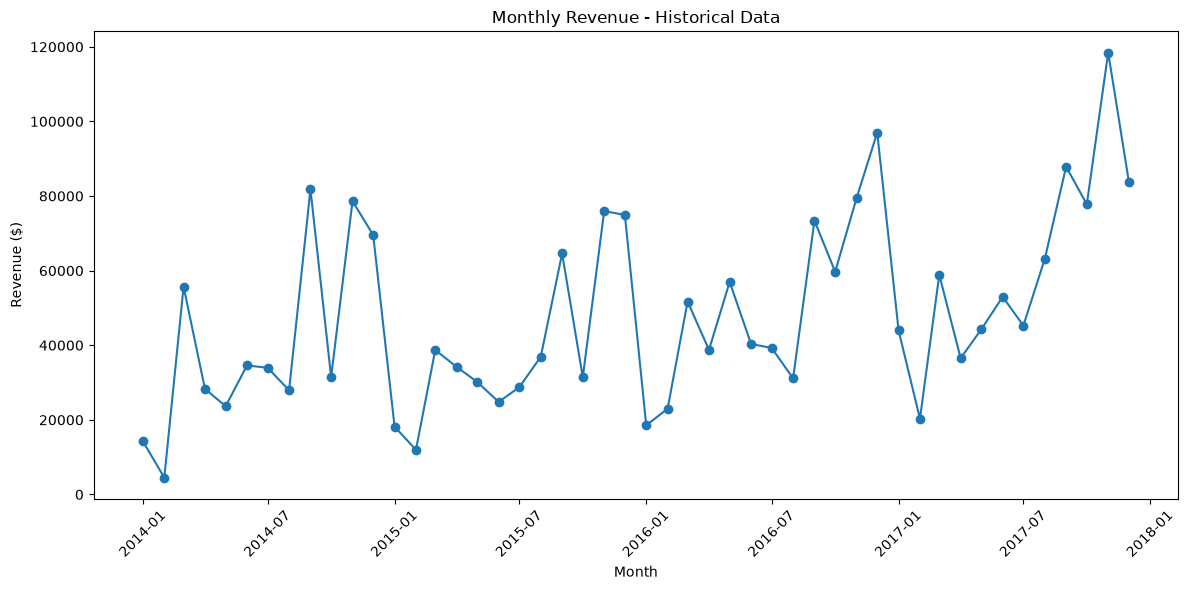

In [16]:
df['month'] = pd.to_datetime(df['month'])

df = df.sort_values(by='month').reset_index (drop=True)

#Visualize the data
plt.figure(figsize=(12,6))
plt.plot(df['month'], df['total_revenue'], marker='o')
plt.title('Monthly Revenue - Historical Data')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

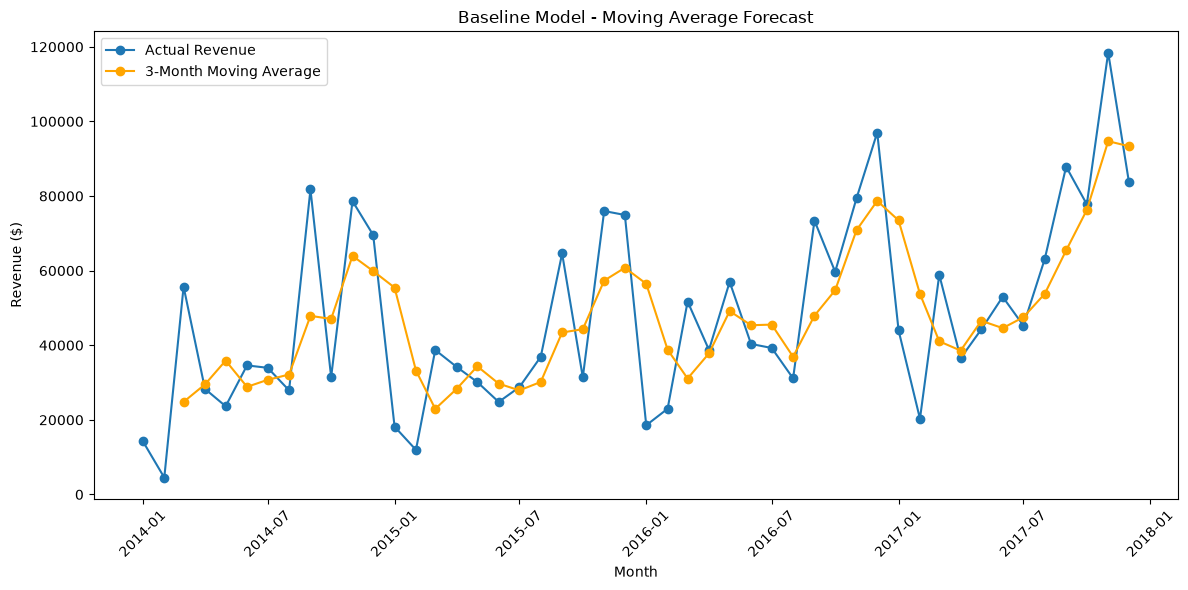

In [17]:
df['moving_avg'] = df['total_revenue'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df['month'], df['total_revenue'], marker='o', label='Actual Revenue')
plt.plot(df['month'], df['moving_avg'], marker='o', label='3-Month Moving Average', color='orange')
plt.title('Baseline Model - Moving Average Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
from prophet import Prophet

prophet_df = df[['month', 'total_revenue']].rename(columns={'month': 'ds', 'total_revenue': 'y'})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=6, freq='ME')
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

22:50:18 - cmdstanpy - INFO - Chain [1] start processing
22:50:18 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
44,2017-09-01,88000.200374,79574.057222,96478.195045
45,2017-10-01,66019.908200,57859.798076,74969.799991
46,2017-11-01,100051.688339,91300.300382,108630.672004
47,2017-12-01,94971.165014,86213.438446,104408.806145
48,2017-12-31,32512.809956,23813.877667,41310.502446
49,2018-01-31,53334.109925,44666.756217,62126.775040
50,2018-02-28,72433.997364,64383.818114,81479.172775
51,2018-03-31,63522.704049,54686.026883,71764.651504
52,2018-04-30,33971.785551,25511.567654,42632.385591
53,2018-05-31,52957.191660,44933.683489,61693.972242


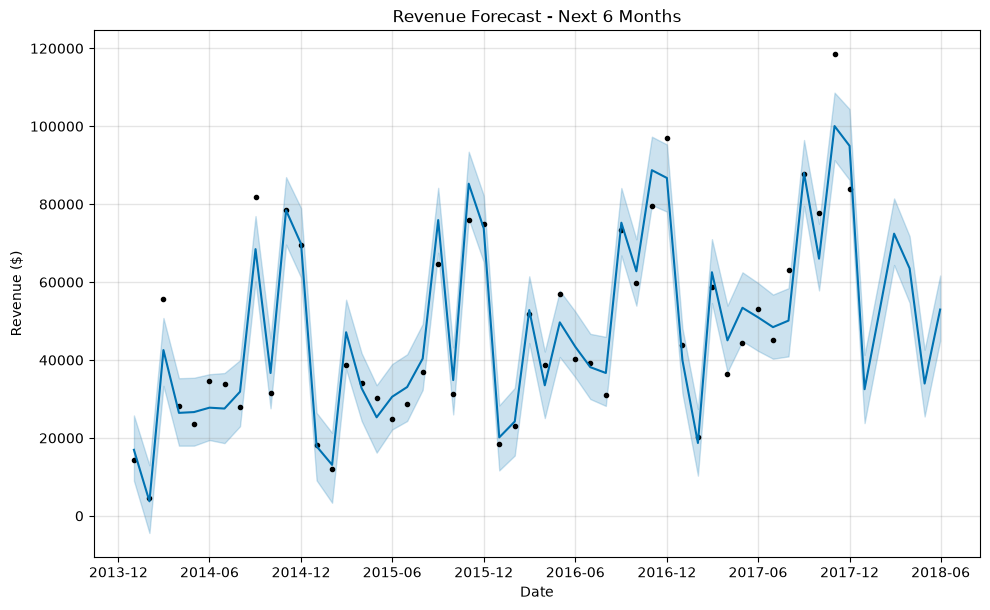

In [19]:
fig = model.plot(forecast)
plt.title('Revenue Forecast - Next 6 Months')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.show()

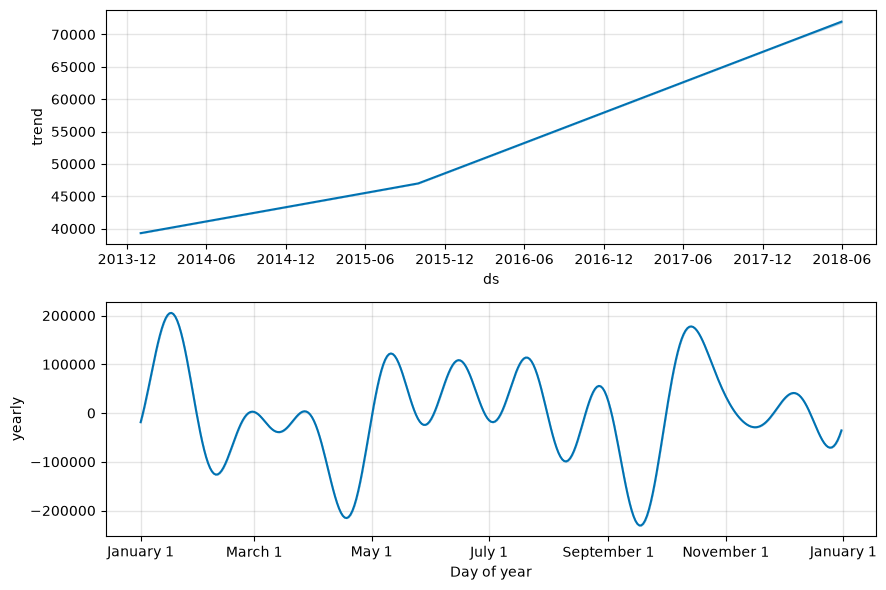

In [20]:
fig2 = model.plot_components(forecast)
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = prophet_df['y'].values
forecast_values = forecast['yhat'][:len(actual)].values

mae = mean_absolute_error(actual, forecast_values)
mse = mean_squared_error(actual, forecast_values)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 5203.24
Root Mean Squared Error (RMSE): 6762.71


In [24]:
baseline_eval = df.dropna(subset=['moving_avg'])

actual_baseline = baseline_eval['total_revenue'].values
predicted_baseline = baseline_eval['moving_avg'].values

mae_baseline = mean_absolute_error(actual_baseline, predicted_baseline)
rmse_baseline = np.sqrt(mean_squared_error(actual_baseline, predicted_baseline))

print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline RMSE: {rmse_baseline:.2f}")

Baseline MAE: 13371.13
Baseline RMSE: 16966.34


In [25]:
comparison = pd.DataFrame({
    'Model': ['Moving Average (Baseline)', 'Prophet'],
    'MAE': [mae_baseline, mae],
    'RMSE': [rmse_baseline, rmse]
})
print(comparison)

                       Model           MAE          RMSE
0  Moving Average (Baseline)  13371.133623  16966.339848
1                    Prophet   5203.236959   6762.713917


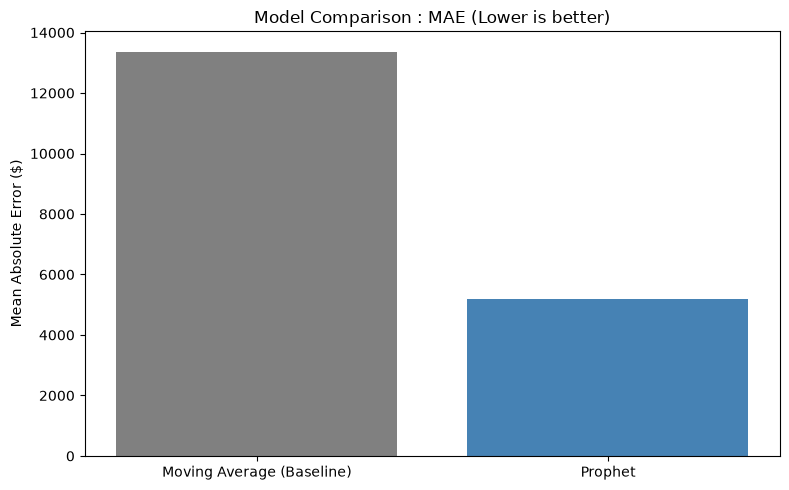

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(comparison['Model'], comparison['MAE'], color=['grey', 'steelblue'])
plt.ylabel('Mean Absolute Error ($)')
plt.title('Model Comparison : MAE (Lower is better)')
plt.tight_layout()
plt.show()

In [27]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('../models/forecast_model.pkl','wb') as f:
    pickle.dump(model,f)

print("Model saved successfully")

Model saved successfully
